# TP — K-NN, Régression Logistique, SVM & Decision Tree (Car Data)

Ce notebook reprend le nettoyage des données réalisé dans le TP K-NN (`Doc 1/Copie de Clas_KNN_on_Car_Data.ipynb`) sur le dataset **Car_Data** (annonces de véhicules à Dakar), puis compare quatre modèles de classification — **K-NN**, **Régression Logistique**, **SVM** et **Decision Tree** — pour prédire si une voiture est **venante** (neuve) ou **d'occasion**.

In [13]:
# Importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
# gérer les warnings
import warnings
warnings.filterwarnings("ignore")

### <font color = 'teal'>Importer et Lire les données<font>

In [18]:
# Importer les données
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/Doc 1/Car_Data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### <font color = "bisque">Concernant les données<font>
Les données ont été scrapées de la page https://www.expat-dakar.com/voitures/dakar. Ce sont des données de véhicules en vente à Dakar. L'objectif de ce TP est de mettre en place des modèles de classification qui, à partir de certaines caractéristiques d'une voiture, prédisent si celle-ci est **venante** (neuve) ou **d'occasion**.

In [19]:
# Afficher les données
df.head()

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant


In [20]:
# Afficher la dimension des données
df.shape

(5507, 6)

In [21]:
# Infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5507 entries, 0 to 5506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Marque           5507 non-null   object
 1   Année            5507 non-null   int64 
 2   Boite_Vitesse    5507 non-null   object
 3   Adresse          5507 non-null   object
 4   Prix             5507 non-null   int64 
 5   Venant_Occasion  5507 non-null   object
dtypes: int64(2), object(4)
memory usage: 258.3+ KB


In [22]:
# Décrire les données
df.describe(include = 'number').T

,count,mean,std,min,25%,50%,75%,max
Année,5507.0,2.014508e+03,3.089839e+00,1990.0,2013.0,2015.0,2016.0,2024.0
Prix,5507.0,1.110512e+07,1.619639e+07,1.0,4600000.0,7800000.0,12500000.0,779414131.0


### <font color = 'gold'>Préparation des données (nettoyage)<font>

In [23]:
# splitter la variable Adresse en Quartier et Region
df[['Quartier', 'Region']] = df.Adresse.str.split(',', n = 1, expand = True)
df.head()

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion,Quartier,Region
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant,Liberte 6,Dakar
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion,Yoff,Dakar
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion,Cité Damel,Dakar
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion,Almadies,Dakar
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant,Hlm,Dakar


In [24]:
# Supprimer les variables Adresse et Region
df.drop(['Adresse', 'Region'], axis = 1, inplace = True)
df.head()

,Marque,Année,Boite_Vitesse,Prix,Venant_Occasion,Quartier
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,D'occasion,Yoff
2,BMW,2015,Automatique,15500000,D'occasion,Cité Damel
3,Ford,2013,Automatique,3800000,D'occasion,Almadies
4,GMC,2014,Automatique,7500000,Venant,Hlm


In [25]:
# Gérer les espaces sur la variable Quartier
df.Quartier = df.Quartier.str.strip()
df.Quartier.unique()

array(['Liberte 6', 'Yoff', 'Cité Damel', 'Almadies', 'Hlm', 'VDN',
       'Plateau', 'Parcelles Assainies', 'Liberte 6 extension',
       'Colobane', 'Sicap foire', 'Fenêtre mermoz', 'Golf', 'Rufisque',
       'Nord foire', 'Ouest foire', 'Sacré-cœur', 'Sicap Liberté',
       'Hann maristes', 'Mbao', 'Gueule-Tapée', 'Amitié', 'Guediawaye',
       'Mermoz', 'Mamelles', 'Pikine', 'Cité keur gorgui', 'Grand-Yoff',
       'Grand-Dakar', 'Fann', 'Keur Massar', 'Hlm grand-yoff',
       'Avenue Bourguiba', 'Castor', 'Médina', 'Patte d‘oie', 'Dieuppeul',
       'Zac Mbao', 'Cambérène', 'Hann Bel-Air', 'Cité biagui', 'Dalifort',
       'Ngor', 'Point-e', 'Liberte 5', 'Bargny', 'Comico', 'Almadies 2',
       'Biscuiterie', 'Sud foire', 'Gibraltar', 'Diamaguene', 'Malika',
       'Tivaouane peulh', 'Bel air', 'Zone de captage', 'Djily mbaye',
       'Sicap Sacré-cœur', 'Yeumbeul', 'Ouakam', 'Liberte 2', 'Virage',
       'Thiaroye', 'Sebikotane', 'Niague', 'Sangalkam', 'Sicap mbao',
       'Liber

In [27]:
# renommer les variables
df.rename(columns = {'Boite_Vitesse': 'Transmission',
                      'Venant_Occasion': 'Etat'}, inplace = True)
df.head()

,Marque,Année,Transmission,Prix,Etat,Quartier
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,D'occasion,Yoff
2,BMW,2015,Automatique,15500000,D'occasion,Cité Damel
3,Ford,2013,Automatique,3800000,D'occasion,Almadies
4,GMC,2014,Automatique,7500000,Venant,Hlm


In [28]:
# Réorganiser les variables
df = df[["Marque", "Année", "Transmission", "Quartier", "Prix", "Etat"]]
df.head()

,Marque,Année,Transmission,Quartier,Prix,Etat
0,Mitsubishi,2017,Automatique,Liberte 6,9750000,Venant
1,Ford,2009,Manuelle,Yoff,2500000,D'occasion
2,BMW,2015,Automatique,Cité Damel,15500000,D'occasion
3,Ford,2013,Automatique,Almadies,3800000,D'occasion
4,GMC,2014,Automatique,Hlm,7500000,Venant


In [29]:
# Importer LabelEncoder et encoder les variables catégorielles
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for colname in df.select_dtypes(include = 'object').columns:
    df[colname] = encoder.fit_transform(df[colname])

df.head()

,Marque,Année,Transmission,Quartier,Prix,Etat
0,30,2017,0,49,9750000,1
1,13,2009,1,83,2500000,0
2,3,2015,0,11,15500000,0
3,13,2013,0,0,3800000,0
4,14,2014,0,38,7500000,1


In [30]:
# Nombre d'observations dans chaque classe de la variable cible
val = df.Etat.value_counts()
val

,count
Etat,
1,2855
0,2652


In [32]:
# Diagramme en barre du nombre d'observations dans chaque classe de la variable cible
fig = px.bar(x = val.index, y = val.values, color = val.index.astype('str'), text_auto = True)
fig.show()

##### <font color = 'bisque'> Fractionnement et normalisation

In [33]:
# Fractionner les données en variables prédicteurs (x) et variable cible (y)
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
x[:5], y[:5]

(array([[      30,     2017,        0,       49,  9750000],
        [      13,     2009,        1,       83,  2500000],
        [       3,     2015,        0,       11, 15500000],
        [      13,     2013,        0,        0,  3800000],
        [      14,     2014,        0,       38,  7500000]]),
 array([1, 0, 0, 0, 1]))

In [34]:
# Normaliser les données avec MinMaxScaler (x = (x - x_min) / (x_max - x_min))
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
x[:5]

array([[0.66666667, 0.79411765, 0.        , 0.57647059, 0.01250939],
       [0.28888889, 0.55882353, 0.5       , 0.97647059, 0.00320754],
       [0.06666667, 0.73529412, 0.        , 0.12941176, 0.01988673],
       [0.28888889, 0.67647059, 0.        , 0.        , 0.00487546],
       [0.31111111, 0.70588235, 0.        , 0.44705882, 0.00962261]])

In [35]:
# Splitter les données en train (80%), val (10%) et test (10%)
from sklearn.model_selection import train_test_split
x_train, x_vt, y_train, y_vt = train_test_split(x, y, train_size = 0.8, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_vt, y_vt, train_size = 0.5, random_state = 42)

x_train.shape, x_val.shape, x_test.shape

((4405, 5), (551, 5), (551, 5))

### <font color = 'gold'>Fonctions d'évaluation<font>

In [37]:
# Accuracy et F1 score sur les données de validation + matrice de confusion
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def evaluation(model):
    y_pred = model.predict(x_val)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    return acc, f1

def evaluation_train(model):
    y_pred = model.predict(x_train)
    print(f'Accuracy sur les données de train : {accuracy_score(y_train, y_pred)}')

def CM_funct(model):
    y_pred = model.predict(x_val)
    cnf_matr = confusion_matrix(y_val, y_pred, labels = [0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix = cnf_matr,
                                   display_labels = ["D'occasion (0)", "Venant (1)"])
    disp.plot()
    plt.title('Matrice de confusion')
    plt.show()

### <font color = 'bisque'> Modélisation<font>

#### <font color = 'teal'>K plus proches voisins (K-NN)<font>

##### <font color = 'bisque'> Fonctionnement mathématique du K-NN

Le **K plus proches voisins** est un algorithme **non paramétrique** et **paresseux** (*lazy learning*) : il mémorise les données d'entraînement et fait tout le calcul au moment de la prédiction.

**Principe** : pour prédire la classe d'une observation $x$, on calcule sa distance à tous les points d'entraînement, on retient les $k$ plus proches, puis on vote à la majorité.

**Distance euclidienne** entre $x$ et $x_i$ (sur $p$ variables) :

$$d(x, x_i) = \sqrt{\sum_{j=1}^{p} \left(x^{(j)} - x_i^{(j)}\right)^2}$$

**Règle de décision** (vote majoritaire parmi les $k$ voisins $N_k(x)$) :

$$\hat{y} = \underset{c}{\text{argmax}} \sum_{i \in N_k(x)} \mathbb{1}(y_i = c)$$

$k$ est choisi par validation croisée (`GridSearchCV`) : trop petit → sur-apprentissage ; trop grand → sous-apprentissage. C'est pour que cette distance ait un sens que les variables ont été normalisées avec `MinMaxScaler`.

In [39]:
# Importer KNeighborsClassifier et GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [40]:
# Recherche du k optimal
knn = KNeighborsClassifier()
k_list = list(range(2, 31))
params_knn = {'n_neighbors': k_list}
grid_knn = GridSearchCV(knn, params_knn, cv = 5)
grid_knn.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                         14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
                                         24, 25, 26, 27, 28, 29, 30]})

In [41]:
# Afficher les paramètres optimaux
grid_knn.best_params_

{'n_neighbors': 23}

In [42]:
# Entraîner le modèle final avec le k optimal
knn_model = KNeighborsClassifier(**grid_knn.best_params_)
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=23)

##### <font color ='bisque'>Evaluation du K-NN<font>

In [43]:
acc_knn, f1_knn = evaluation(knn_model)
print(f'Accuracy : {acc_knn: .3f} ---- F1 {f1_knn: .3f}')

Accuracy :  0.782 ---- F1  0.809


In [44]:
evaluation_train(knn_model)

Accuracy sur les données de train : 0.7920544835414302


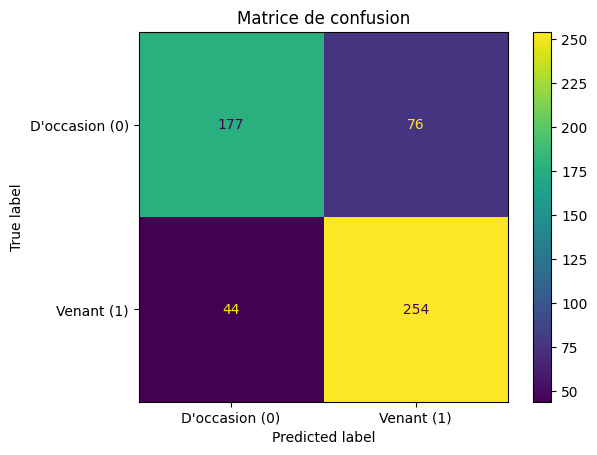

In [45]:
CM_funct(knn_model)

#### <font color = 'teal'>Régression Logistique<font>

##### <font color = 'bisque'> Fonctionnement mathématique de la Régression Logistique

Modèle **linéaire** et **paramétrique** de classification.

**Combinaison linéaire** puis **sigmoïde** pour obtenir une probabilité :

$$z = \beta_0 + \sum_{j=1}^{p}\beta_j x_j \qquad P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

**Frontière de décision** (seuil 0.5, équivalent à $z = 0$, un hyperplan) :

$$\hat{y} = 1 \text{ si } P(y=1\mid x) \geq 0.5,\ \text{sinon } 0$$

**Fonction de coût** minimisée (entropie croisée) :

$$J(\beta) = -\frac{1}{n}\sum_{i=1}^{n} \Big[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \Big]$$

**Régularisation** contrôlée par `C` (inverse de $\lambda$) : L2 pénalise $\sum \beta_j^2$, L1 pénalise $\sum |\beta_j|$ (peut annuler des coefficients). `GridSearchCV` teste plusieurs `C`, `penalty` et `solver`.

In [46]:
# Recherche des paramètres optimaux pour la Régression Logistique
from sklearn.linear_model import LogisticRegression
params_lg = {"C": np.logspace(-3, 3, 7), "penalty": ['l1', 'l2'],
             'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']}
lg = LogisticRegression()
grid_lg = GridSearchCV(lg, params_lg, cv = 5)
grid_lg.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'penalty': ['l1', 'l2'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag',
                                    'saga']})

In [47]:
# Afficher les paramètres optimaux
grid_lg.best_params_

{'C': np.float64(100.0), 'penalty': 'l1', 'solver': 'liblinear'}

In [48]:
# Entraîner le modèle avec les paramètres optimaux
lg_model = LogisticRegression(**grid_lg.best_params_)
lg_model.fit(x_train, y_train)

LogisticRegression(C=np.float64(100.0), penalty='l1', solver='liblinear')

##### <font color ='bisque'>Evaluation de la Régression Logistique<font>

In [49]:
acc_lg, f1_lg = evaluation(lg_model)
print(f'Accuracy : {acc_lg: .3f} ---- F1 {f1_lg: .3f}')

Accuracy :  0.780 ---- F1  0.799


In [50]:
evaluation_train(lg_model)

Accuracy sur les données de train : 0.7691259931895573


In [ ]:
CM_funct(lg_model)

#### <font color = 'teal'>Support Vector Machine (SVM)<font>

##### <font color = 'bisque'> Fonctionnement mathématique du SVM

Le SVM cherche l'**hyperplan séparateur** qui **maximise la marge** entre les classes, en s'appuyant uniquement sur les points les plus proches de la frontière (**vecteurs de support**) :

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i \quad \text{sous contrainte} \quad y_i(w\cdot x_i + b) \geq 1-\xi_i,\ \xi_i \geq 0$$

`C` contrôle le compromis marge large / erreurs tolérées : `C` grand → marge étroite (risque de sur-apprentissage), `C` petit → marge large (plus régularisé).

**Kernel trick** : pour des frontières non-linéaires, on utilise un noyau comme le **RBF (gaussien)**, qui mesure la similarité entre deux points sans calculer explicitement leur projection dans un espace de plus grande dimension :

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

`GridSearchCV` teste ici plusieurs valeurs de `C` et les noyaux `linear`/`rbf`.

In [51]:
# Recherche des paramètres optimaux pour le SVM
from sklearn.svm import SVC
params_svm = {'C': np.logspace(-1, 3, 5), 'kernel': ['linear', 'rbf']}
svm = SVC()
grid_svm = GridSearchCV(svm, params_svm, cv = 5)
grid_svm.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': array([1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'kernel': ['linear', 'rbf']})

In [52]:
# Afficher les paramètres optimaux
grid_svm.best_params_

{'C': np.float64(1000.0), 'kernel': 'rbf'}

In [53]:
# Entraîner le modèle avec les paramètres optimaux
svm_model = SVC(**grid_svm.best_params_)
svm_model.fit(x_train, y_train)

SVC(C=np.float64(1000.0))

##### <font color ='bisque'>Evaluation du SVM<font>

In [54]:
acc_svm, f1_svm = evaluation(svm_model)
print(f'Accuracy : {acc_svm: .3f} ---- F1 {f1_svm: .3f}')

Accuracy :  0.788 ---- F1  0.811


In [55]:
evaluation_train(svm_model)

Accuracy sur les données de train : 0.8056753688989784


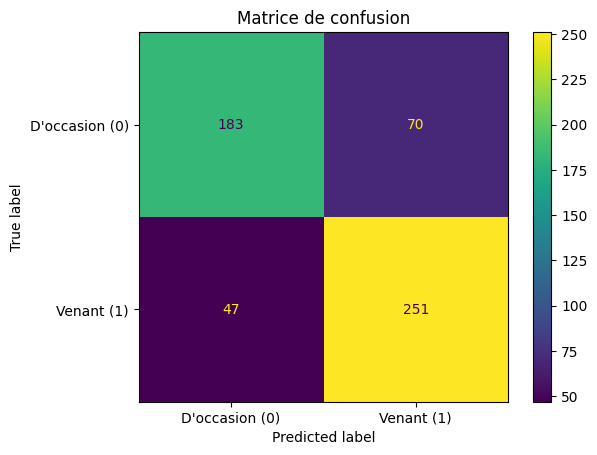

In [56]:
CM_funct(svm_model)

#### <font color = 'teal'>Decision Tree<font>

##### <font color = 'bisque'> Fonctionnement mathématique du Decision Tree

L'arbre de décision partitionne récursivement l'espace des variables via des règles "si $x_j \le s$ alors ... sinon ...", pour rendre chaque nœud le plus **pur** possible.

**Indice de Gini** (proportion $p_k$ de la classe $k$ dans le nœud) :

$$Gini = 1 - \sum_{k=1}^{K} p_k^2$$

**Entropie** (alternative) :

$$Entropie = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

**Critère de coupure** : on choisit la variable/seuil qui maximise le **gain** (réduction d'impureté) :

$$\text{Gain}(D, x_j, s) = I(D) - \left(\frac{n_g}{n} I(D_g) + \frac{n_d}{n} I(D_d)\right)$$

La classe prédite pour une nouvelle observation est la classe majoritaire de la feuille atteinte. `max_depth` limite la profondeur de l'arbre pour éviter le sur-apprentissage ; `GridSearchCV` teste `criterion` (`gini`/`entropy`) et `max_depth`.

In [57]:
# Recherche des paramètres optimaux pour le Decision Tree
from sklearn.tree import DecisionTreeClassifier
params_dt = {'criterion': ['gini', 'entropy'], 'max_depth': np.arange(3, 15)}
dt = DecisionTreeClassifier()
grid_dt = GridSearchCV(dt, params_dt, cv = 5)
grid_dt.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])})

In [58]:
# Afficher les paramètres optimaux
grid_dt.best_params_

{'criterion': 'gini', 'max_depth': np.int64(6)}

In [59]:
# Entraîner le modèle avec les paramètres optimaux
dt_model = DecisionTreeClassifier(**grid_dt.best_params_)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(6))

##### <font color ='bisque'>Evaluation du Decision Tree<font>

In [60]:
acc_dt, f1_dt = evaluation(dt_model)
print(f'Accuracy : {acc_dt: .3f} ---- F1 {f1_dt: .3f}')

Accuracy :  0.809 ---- F1  0.835


In [ ]:
evaluation_train(dt_model)

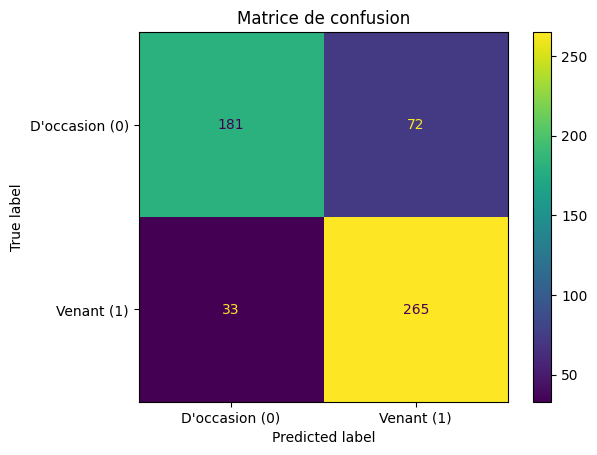

In [61]:
CM_funct(dt_model)

### <font color ='bisque'>Comparaison des modèles<font>

In [63]:
list_acc = [acc_knn, acc_lg, acc_svm, acc_dt]
list_f1 = [f1_knn, f1_lg, f1_svm, f1_dt]
list_names = ['knn', 'lg', 'svm', 'dt']

for liste in [list_acc, list_f1]:
    fig = px.bar(y = list_names, x = liste, color = list_names, text_auto = True)
    fig.show()

### <font color ='bisque'>Tester le modèle le plus performant<font>

In [ ]:
# Sélectionner automatiquement le modèle avec la meilleure accuracy (validation)
models = {'knn': knn_model, 'lg': lg_model, 'svm': svm_model, 'dt': dt_model}
best_name = list_names[int(np.argmax(list_acc))]
best_model = models[best_name]
print(f'Meilleur modèle : {best_name}')

x_test_10 = x_test[:10]
y_test_10 = y_test[:10]
class_names = ["D'occasion", 'Venant']
y_predict_10 = best_model.predict(x_test_10)
for i in range(10):
    print(f'Prediction {i+1} : {class_names[y_predict_10[i]]} | Réel {i+1} : {class_names[y_test_10[i]]}')

In [ ]:
# Accuracy finale du meilleur modèle sur les données de test
y_pred_test = best_model.predict(x_test)
print(f'Accuracy du meilleur modèle ({best_name}) sur le test : {accuracy_score(y_test, y_pred_test): .3f}')